# Convergence Study: `N` and `t_eval_count` Parameters

The `simulate()` function has two tuneable parameters that control numerical resolution:

- **`N`** — number of radial grid points in the finite-difference scheme (spatial resolution)
- **`t_eval_count`** — number of time evaluation points in the output (temporal resolution)

This notebook systematically evaluates their effect on precision and runtime across all materials, then recommends values for three use-cases:

| Use-case | Goal |
|---|---|
| **Dashboard** | Interactive — fast enough for real-time slider updates |
| **Single experiment** | High-precision analysis and reporting |
| **Optimizer** | Balanced — called hundreds/thousands of times |

## 1. Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dryer_core.dryer import DryerConfig, FilamentConfig, simulate
from dryer_core.materials import MATERIALS

## 2. Baseline Configurations

Standard dryer settings and per-material filament configs with typical initial moisture levels.

In [2]:
dryer = DryerConfig(
    chamber_length=0.5,
    chamber_temp=80.0,
    ambient_humidity=0.50,
    ambient_temp=25.0,
    airflow_velocity=1.0,
)

# Representative initial moisture for each material (moderately moist)
initial_moistures = {
    "PA6": 0.04,   # 4 wt% — Nylon absorbs a lot
    "PETG": 0.004, # 0.4 wt%
    "PLA": 0.005,  # 0.5 wt%
    "TPU": 0.008,  # 0.8 wt%
    "PVA": 0.06,   # 6 wt% — very hygroscopic
    "ABS": 0.003,  # 0.3 wt%
}

filaments = {
    key: FilamentConfig(
        material=mat,
        initial_moisture=initial_moistures[key],
        flow_rate=8.0,
    )
    for key, mat in MATERIALS.items()
}

# Summary table
rows = []
for key, fil in filaments.items():
    D = fil.material.diffusivity(dryer.chamber_temp)
    transit = dryer.chamber_length / fil.speed
    R = fil.diameter / 2.0
    Fo = D * transit / R**2
    rows.append({
        "Material": fil.material.name,
        "D(80°C) [m²/s]": f"{D:.2e}",
        "M_eq [wt%]": f"{fil.material.equilibrium_moisture * 100:.1f}",
        "M_init [wt%]": f"{fil.initial_moisture * 100:.1f}",
        "Transit [s]": f"{transit:.1f}",
        "Fo": f"{Fo:.2e}",
    })

pd.DataFrame(rows)

,Material,D(80°C) [m²/s],M_eq [wt%],M_init [wt%],Transit [s],Fo
0,PA6 (Nylon 6),1.56e-10,7.0,4.0,150.3,3.06e-02
1,PETG,1.45e-11,0.5,0.4,150.3,2.85e-03
2,PLA,1.21e-11,0.8,0.5,150.3,2.38e-03
3,TPU,4.79e-11,1.2,0.8,150.3,9.40e-03
4,PVA,3.79e-10,10.0,6.0,150.3,7.43e-02
5,ABS,1.92e-11,0.4,0.3,150.3,3.76e-03


## 3. High-Fidelity Reference Solutions

Run each material at `N=500, t_eval_count=5000` to establish ground-truth values.

In [3]:
N_REF, T_REF = 500, 5000

refs = {}
for key, fil in filaments.items():
    t0 = time.perf_counter()
    res = simulate(dryer, fil, N=N_REF, t_eval_count=T_REF)
    dt = time.perf_counter() - t0
    refs[key] = res
    print(f"{fil.material.name:20s}  final_moisture={res.final_moisture*100:.6f} wt%  ({dt:.2f}s)")

PA6 (Nylon 6)         final_moisture=2.632368 wt%  (11.07s)
PETG                  final_moisture=0.354855 wt%  (8.14s)
PLA                   final_moisture=0.448994 wt%  (17.12s)
TPU                   final_moisture=0.640863 wt%  (6.64s)
PVA                   final_moisture=2.959496 wt%  (5.49s)
ABS                   final_moisture=0.261391 wt%  (3.46s)


## 4. Sweep N (Radial Grid Points)

`t_eval_count` fixed at 2000 (high). Vary `N` and measure error in `final_moisture` relative to the reference.

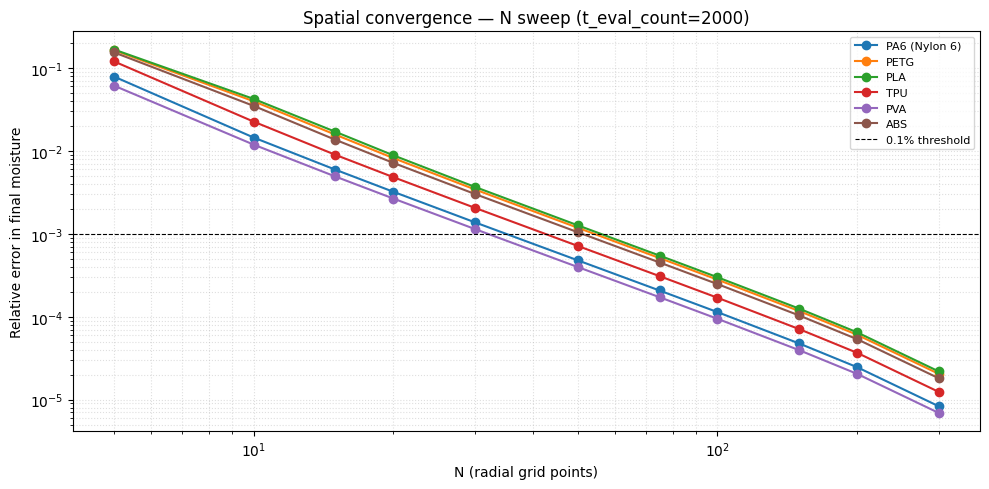

In [4]:
N_values = [5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300]
T_FIXED = 2000

n_sweep = {}  # key -> list of dicts
for key, fil in filaments.items():
    ref_moisture = refs[key].final_moisture
    records = []
    for N in N_values:
        t0 = time.perf_counter()
        res = simulate(dryer, fil, N=N, t_eval_count=T_FIXED)
        dt = time.perf_counter() - t0
        abs_err = abs(res.final_moisture - ref_moisture)
        rel_err = abs_err / ref_moisture if ref_moisture != 0 else abs_err
        # RMSE of C_avg trajectory (interpolate to reference time grid)
        c_interp = np.interp(refs[key].diffusion.t, res.diffusion.t, res.diffusion.C_avg)
        rmse = np.sqrt(np.mean((c_interp - refs[key].diffusion.C_avg) ** 2))
        records.append({"N": N, "abs_err": abs_err, "rel_err": rel_err, "rmse": rmse, "time_s": dt})
    n_sweep[key] = records

# Plot convergence
fig, ax = plt.subplots(figsize=(10, 5))
for key, records in n_sweep.items():
    ns = [r["N"] for r in records]
    errs = [r["rel_err"] for r in records]
    ax.plot(ns, errs, "o-", label=MATERIALS[key].name)

ax.axhline(1e-3, color="k", ls="--", lw=0.8, label="0.1% threshold")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("N (radial grid points)")
ax.set_ylabel("Relative error in final moisture")
ax.set_title("Spatial convergence — N sweep (t_eval_count=2000)")
ax.legend(fontsize=8)
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()

## 5. Sweep `t_eval_count` (Temporal Resolution)

`N` fixed at 200 (high). Vary `t_eval_count` — this controls output sampling points, **not** the internal adaptive solver steps (BDF with rtol=1e-8), so expect minimal impact on the final moisture value.

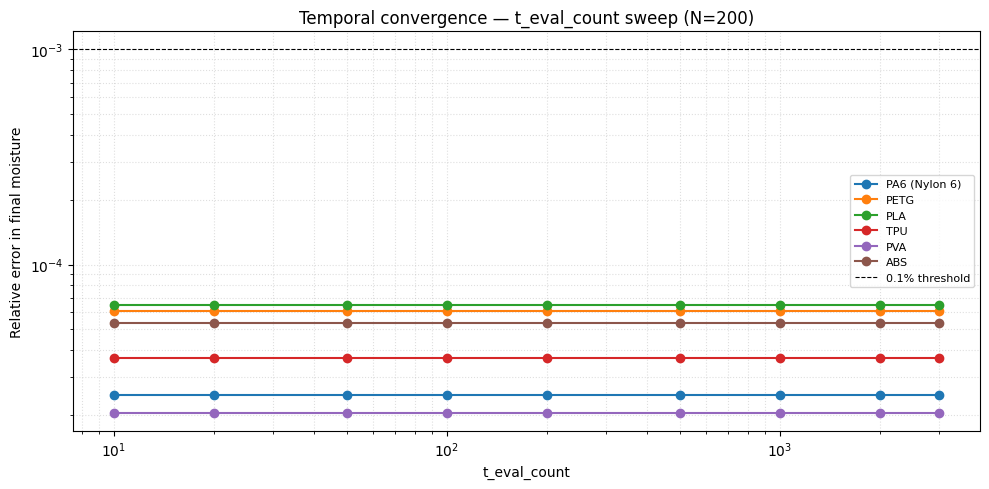

In [5]:
T_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000]
N_FIXED = 200

t_sweep = {}
for key, fil in filaments.items():
    ref_moisture = refs[key].final_moisture
    records = []
    for T in T_values:
        t0 = time.perf_counter()
        res = simulate(dryer, fil, N=N_FIXED, t_eval_count=T)
        dt = time.perf_counter() - t0
        abs_err = abs(res.final_moisture - ref_moisture)
        rel_err = abs_err / ref_moisture if ref_moisture != 0 else abs_err
        c_interp = np.interp(refs[key].diffusion.t, res.diffusion.t, res.diffusion.C_avg)
        rmse = np.sqrt(np.mean((c_interp - refs[key].diffusion.C_avg) ** 2))
        records.append({"t_eval": T, "abs_err": abs_err, "rel_err": rel_err, "rmse": rmse, "time_s": dt})
    t_sweep[key] = records

fig, ax = plt.subplots(figsize=(10, 5))
for key, records in t_sweep.items():
    ts = [r["t_eval"] for r in records]
    errs = [r["rel_err"] for r in records]
    ax.plot(ts, errs, "o-", label=MATERIALS[key].name)

ax.axhline(1e-3, color="k", ls="--", lw=0.8, label="0.1% threshold")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("t_eval_count")
ax.set_ylabel("Relative error in final moisture")
ax.set_title("Temporal convergence — t_eval_count sweep (N=200)")
ax.legend(fontsize=8)
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()

## 6. 2D Error Surface — N × `t_eval_count`

Pick **PA6 (Nylon)** — the most challenging material (highest diffusivity → steepest gradients). Map relative error across the full parameter space.

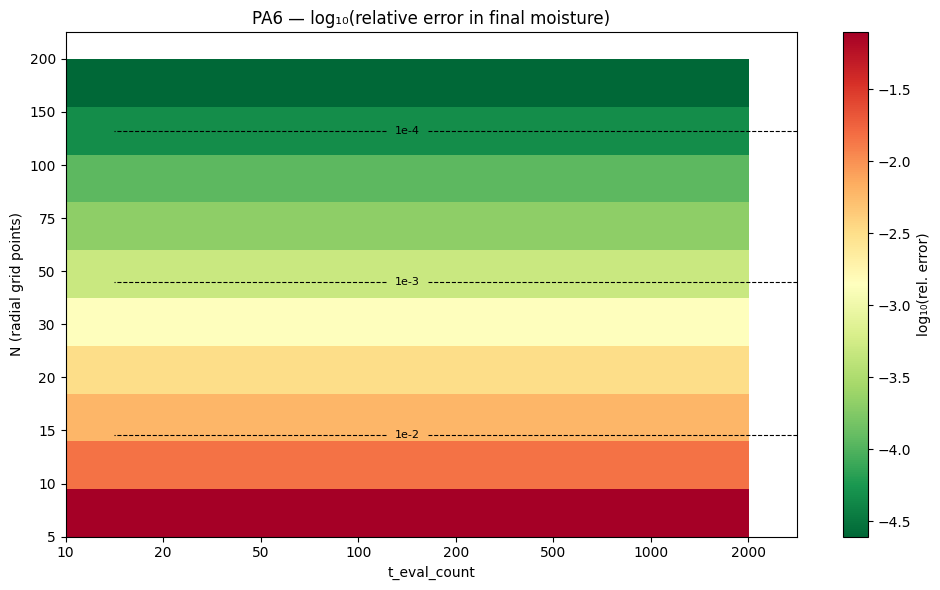

In [6]:
grid_N = [5, 10, 15, 20, 30, 50, 75, 100, 150, 200]
grid_T = [10, 20, 50, 100, 200, 500, 1000, 2000]

fil_pa6 = filaments["PA6"]
ref_pa6 = refs["PA6"].final_moisture

err_grid = np.zeros((len(grid_N), len(grid_T)))
time_grid = np.zeros_like(err_grid)

for i, N in enumerate(grid_N):
    for j, T in enumerate(grid_T):
        t0 = time.perf_counter()
        res = simulate(dryer, fil_pa6, N=N, t_eval_count=T)
        time_grid[i, j] = time.perf_counter() - t0
        err_grid[i, j] = abs(res.final_moisture - ref_pa6) / ref_pa6

fig, ax = plt.subplots(figsize=(10, 6))
log_err = np.log10(np.clip(err_grid, 1e-16, None))
im = ax.imshow(
    log_err, origin="lower", aspect="auto",
    extent=[0, len(grid_T) - 1, 0, len(grid_N) - 1],
    cmap="RdYlGn_r",
)
ax.set_xticks(range(len(grid_T)))
ax.set_xticklabels(grid_T)
ax.set_yticks(range(len(grid_N)))
ax.set_yticklabels(grid_N)
ax.set_xlabel("t_eval_count")
ax.set_ylabel("N (radial grid points)")
ax.set_title("PA6 — log₁₀(relative error in final moisture)")
cb = fig.colorbar(im, ax=ax)
cb.set_label("log₁₀(rel. error)")

# Overlay iso-error contours
CS = ax.contour(
    log_err, levels=[-5, -4, -3, -2, -1],
    colors="k", linewidths=0.8, origin="lower",
)
ax.clabel(CS, fmt="1e%d", fontsize=8)
plt.tight_layout()

## 7. Convergence Analysis Across Materials

Minimum `N` to achieve < 0.1% relative error (at `t_eval_count=2000`), and minimum `t_eval_count` to achieve < 0.1% (at `N=200`).

     Material  Min N (<0.1%)  Min t_eval (<0.1%)       Fo
PA6 (Nylon 6)             50                  10 3.06e-02
         PETG             75                  10 2.85e-03
          PLA             75                  10 2.38e-03
          TPU             50                  10 9.40e-03
          PVA             50                  10 7.43e-02
          ABS             75                  10 3.76e-03


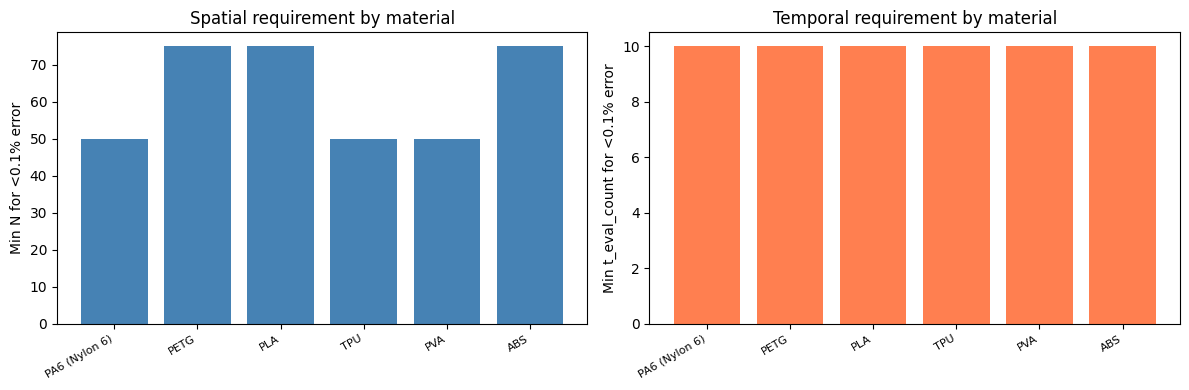

In [7]:
THRESHOLD = 1e-3  # 0.1%

summary_rows = []
for key in filaments:
    # Min N for <0.1% error
    min_N = None
    for r in n_sweep[key]:
        if r["rel_err"] < THRESHOLD:
            min_N = r["N"]
            break

    # Min t_eval for <0.1% error
    min_T = None
    for r in t_sweep[key]:
        if r["rel_err"] < THRESHOLD:
            min_T = r["t_eval"]
            break

    summary_rows.append({
        "Material": MATERIALS[key].name,
        "Min N (<0.1%)": min_N if min_N else f">{N_values[-1]}",
        "Min t_eval (<0.1%)": min_T if min_T else f">{T_values[-1]}",
        "Fo": f"{refs[key].fourier_number:.2e}",
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mat_names = [r["Material"] for r in summary_rows]
x = np.arange(len(mat_names))

# N bars
n_vals = [r["Min N (<0.1%)"] for r in summary_rows]
n_nums = [v if isinstance(v, int) else 999 for v in n_vals]
axes[0].bar(x, n_nums, color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(mat_names, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("Min N for <0.1% error")
axes[0].set_title("Spatial requirement by material")

# t_eval bars
t_vals = [r["Min t_eval (<0.1%)"] for r in summary_rows]
t_nums = [v if isinstance(v, int) else 9999 for v in t_vals]
axes[1].bar(x, t_nums, color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(mat_names, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Min t_eval_count for <0.1% error")
axes[1].set_title("Temporal requirement by material")

plt.tight_layout()

## 8. Computation Time vs. Accuracy Tradeoff

Dual-axis plots showing error and wall-clock time, plus a Pareto frontier from the 2D PA6 grid.

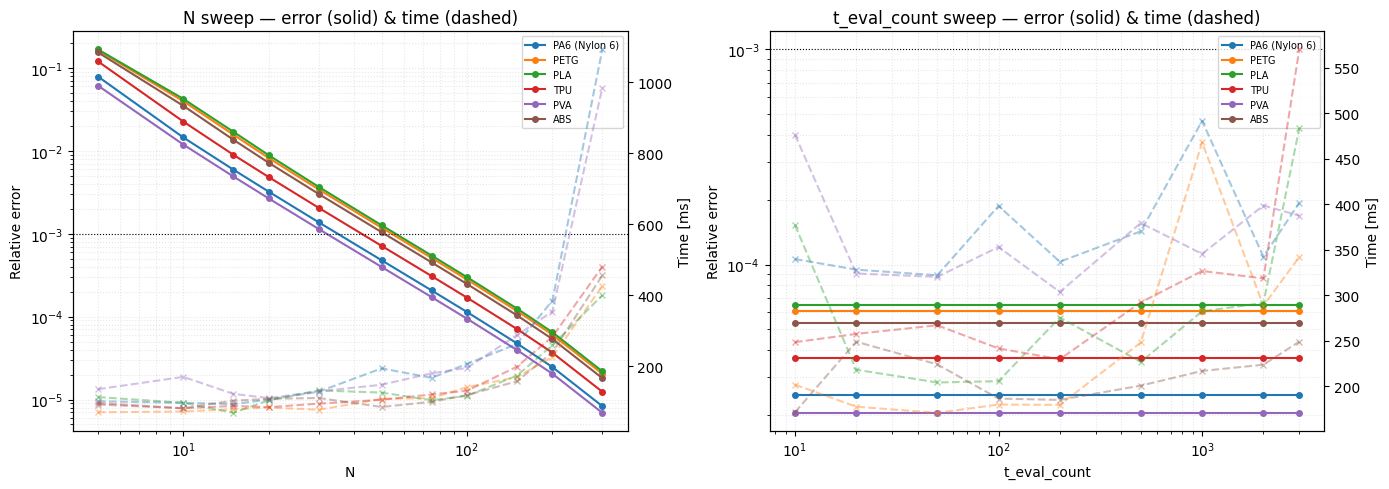

In [8]:
# --- N sweep: error + time dual axis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: N sweep
ax1 = axes[0]
ax1t = ax1.twinx()
for key, records in n_sweep.items():
    ns = [r["N"] for r in records]
    errs = [r["rel_err"] for r in records]
    times = [r["time_s"] * 1000 for r in records]  # ms
    ax1.plot(ns, errs, "o-", label=MATERIALS[key].name, markersize=4)
    ax1t.plot(ns, times, "x--", alpha=0.4, markersize=4)

ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("N"); ax1.set_ylabel("Relative error")
ax1t.set_ylabel("Time [ms]")
ax1.set_title("N sweep — error (solid) & time (dashed)")
ax1.axhline(1e-3, color="k", ls=":", lw=0.8)
ax1.legend(fontsize=7, loc="upper right")
ax1.grid(True, which="both", ls=":", alpha=0.3)

# Right: t_eval sweep
ax2 = axes[1]
ax2t = ax2.twinx()
for key, records in t_sweep.items():
    ts = [r["t_eval"] for r in records]
    errs = [r["rel_err"] for r in records]
    times = [r["time_s"] * 1000 for r in records]
    ax2.plot(ts, errs, "o-", label=MATERIALS[key].name, markersize=4)
    ax2t.plot(ts, times, "x--", alpha=0.4, markersize=4)

ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("t_eval_count"); ax2.set_ylabel("Relative error")
ax2t.set_ylabel("Time [ms]")
ax2.set_title("t_eval_count sweep — error (solid) & time (dashed)")
ax2.axhline(1e-3, color="k", ls=":", lw=0.8)
ax2.legend(fontsize=7, loc="upper right")
ax2.grid(True, which="both", ls=":", alpha=0.3)

plt.tight_layout()

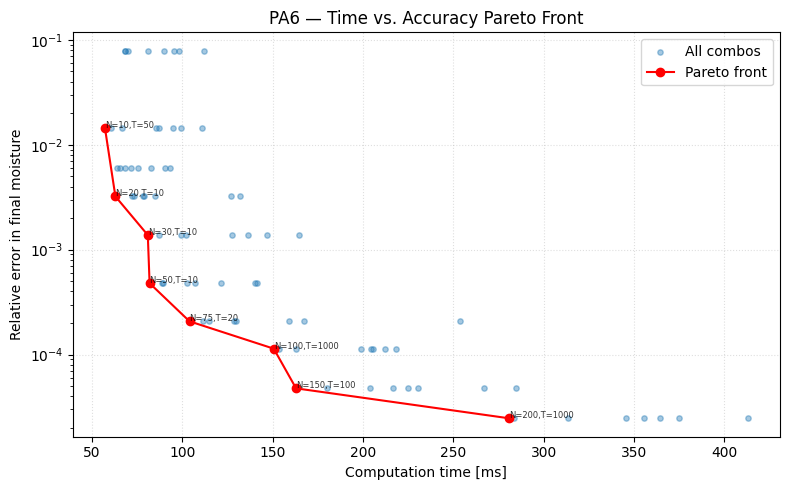

In [9]:
# Pareto frontier from the 2D PA6 grid
points = []
for i, N in enumerate(grid_N):
    for j, T in enumerate(grid_T):
        points.append((err_grid[i, j], time_grid[i, j], N, T))

# Sort by time, then find Pareto front (non-dominated: lower error AND lower time)
points.sort(key=lambda x: x[1])
pareto = []
best_err = float("inf")
for p in points:
    if p[0] < best_err:
        pareto.append(p)
        best_err = p[0]

fig, ax = plt.subplots(figsize=(8, 5))
all_errs = [p[0] for p in points]
all_times = [p[1] * 1000 for p in points]
ax.scatter(all_times, all_errs, s=15, alpha=0.4, label="All combos")

pareto_t = [p[1] * 1000 for p in pareto]
pareto_e = [p[0] for p in pareto]
ax.plot(pareto_t, pareto_e, "r-o", markersize=6, label="Pareto front")
for p in pareto:
    ax.annotate(f"N={p[2]},T={p[3]}", (p[1]*1000, p[0]), fontsize=6, alpha=0.8)

ax.set_xlabel("Computation time [ms]")
ax.set_ylabel("Relative error in final moisture")
ax.set_yscale("log")
ax.set_title("PA6 — Time vs. Accuracy Pareto Front")
ax.legend()
ax.grid(True, ls=":", alpha=0.4)
plt.tight_layout()

## 9. Recommended Parameter Presets

Based on the convergence and timing analysis, three presets:

| Preset | Target | Notes |
|---|---|---|
| **dashboard** | Fast interactive updates, < 1% error | Sliders need ~60 fps → budget ~50 ms |
| **single_experiment** | High-precision reporting, < 0.01% error | One-shot, time isn't critical |
| **optimizer** | Balanced for 100s–1000s of calls | < 0.1% error, minimal overhead |

In [10]:
# Candidate presets (will validate below)
PRESETS = {
    "dashboard":          {"N": 20, "t_eval_count": 100},
    "single_experiment":  {"N": 100, "t_eval_count": 500},
    "optimizer":          {"N": 30, "t_eval_count": 50},
}

# Validate across all materials
validation_rows = []
for preset_name, params in PRESETS.items():
    for key, fil in filaments.items():
        ref_m = refs[key].final_moisture
        t0 = time.perf_counter()
        res = simulate(dryer, fil, **params)
        dt = time.perf_counter() - t0
        rel_err = abs(res.final_moisture - ref_m) / ref_m if ref_m != 0 else 0.0
        validation_rows.append({
            "Preset": preset_name,
            "Material": MATERIALS[key].name,
            "N": params["N"],
            "t_eval": params["t_eval_count"],
            "Final moisture [wt%]": f"{res.final_moisture * 100:.5f}",
            "Ref [wt%]": f"{ref_m * 100:.5f}",
            "Rel. error": f"{rel_err:.2e}",
            "Time [ms]": f"{dt * 1000:.1f}",
        })

df_val = pd.DataFrame(validation_rows)
print(df_val.to_string(index=False))

# Compact summary per preset
print("\n" + "=" * 70)
print("PRESET SUMMARY")
print("=" * 70)
for preset_name, params in PRESETS.items():
    subset = [r for r in validation_rows if r["Preset"] == preset_name]
    worst_err = max(float(r["Rel. error"]) for r in subset)
    max_time = max(float(r["Time [ms]"]) for r in subset)
    print(f"  {preset_name:20s}  N={params['N']:>4d}  t_eval={params['t_eval_count']:>5d}"
          f"  worst_error={worst_err:.2e}  max_time={max_time:.1f} ms")

           Preset      Material   N  t_eval Final moisture [wt%] Ref [wt%] Rel. error Time [ms]
        dashboard PA6 (Nylon 6)  20     100              2.62389   2.63237   3.22e-03      82.8
        dashboard          PETG  20     100              0.35194   0.35485   8.21e-03      48.7
        dashboard           PLA  20     100              0.44501   0.44899   8.86e-03      49.2
        dashboard           TPU  20     100              0.63777   0.64086   4.83e-03      71.5
        dashboard           PVA  20     100              2.95160   2.95950   2.67e-03      98.9
        dashboard           ABS  20     100              0.25951   0.26139   7.18e-03      72.5
single_experiment PA6 (Nylon 6) 100     500              2.63207   2.63237   1.14e-04     150.9
single_experiment          PETG 100     500              0.35476   0.35485   2.80e-04     103.0
single_experiment           PLA 100     500              0.44886   0.44899   3.00e-04     106.3
single_experiment           TPU 100     